Comparing the emergency visits of male age group (40-50) with the emergency visits of female age group (40-50)

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
health_data = pd.read_csv('https://raw.githubusercontent.com/niteen11/DataAnalyticsAcademy/master/Python/dataset_diabetes/diabetic_data.csv')

In [23]:
health_data.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [24]:
health_data.tail()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO
101765,443867222,175429310,Caucasian,Male,[70-80),?,1,1,7,6,...,No,No,No,No,No,No,No,No,No,NO


In [25]:
health_data.shape

(101766, 50)

In [33]:
health_data.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [46]:
health_data = health_data[health_data['age'] == '[40-50)']


In [47]:
columns_to_keep = ['encounter_id', 'patient_nbr', 'gender', 'age', 'number_emergency']
health_data = health_data[columns_to_keep]


In [48]:
print("New DataFrame shape after reloading and filtering:", health_data.shape)
print("Unique ages after filtering:", health_data['age'].unique())
display(health_data.head())

New DataFrame shape after reloading and filtering: (9685, 5)
Unique ages after filtering: ['[40-50)']


,encounter_id,patient_nbr,gender,age,number_emergency
4,16680,42519267,Male,[40-50),0
10,28236,89869032,Female,[40-50),0
12,40926,85504905,Female,[40-50),1
41,419304,99715041,Male,[40-50),0
45,464994,106936875,Female,[40-50),0


In [49]:
health_data_m = health_data[health_data['gender'] != 'Female']
print("New DataFrame shape:", health_data_m.shape)
print("Unique genders after filtering:", health_data['gender'].unique())
health_data_m.head()

New DataFrame shape: (4874, 5)
Unique genders after filtering: ['Male' 'Female']


,encounter_id,patient_nbr,gender,age,number_emergency
4,16680,42519267,Male,[40-50),0
41,419304,99715041,Male,[40-50),0
57,654918,3146373,Male,[40-50),0
85,1119858,68661747,Male,[40-50),0
89,1157574,91181331,Male,[40-50),0


In [50]:
health_data_f = health_data[health_data['gender'] != 'Male']
print("New DataFrame shape:", health_data_f.shape)
print("Unique genders after filtering:", health_data['gender'].unique())
health_data_f.head()

New DataFrame shape: (4811, 5)
Unique genders after filtering: ['Male' 'Female']


,encounter_id,patient_nbr,gender,age,number_emergency
10,28236,89869032,Female,[40-50),0
12,40926,85504905,Female,[40-50),1
45,464994,106936875,Female,[40-50),0
52,590346,37746639,Female,[40-50),0
62,682494,64729746,Female,[40-50),0


In [51]:
mean_emergencyvisit_m = health_data_m['number_emergency'].mean()
print(f"The average emergency visits for males aged 40-50 :{mean_emergencyvisit_m:.2f}")

The average emergency visits for males aged 40-50 :0.29


In [52]:
mean_emergencyvisit_f = health_data_f['number_emergency'].mean()
print(f"The average emergency visits for females aged 40-50 :{mean_emergencyvisit_f:.2f}")

The average emergency visits for females aged 40-50 :0.42


/tmp/ipykernel_198/2690737180.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gender', y='Average Emergency Visits', data=comparison_df, palette={'Male': 'skyblue', 'Female': 'lightcoral'})


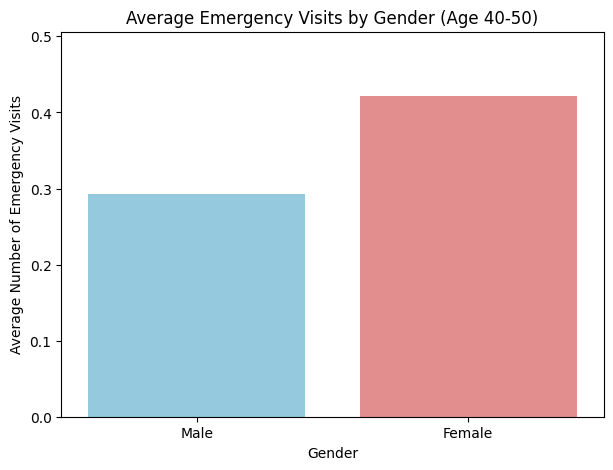

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for easier plotting
comparison_df = pd.DataFrame({
    'Gender': ['Male', 'Female'],
    'Average Emergency Visits': [mean_emergencyvisit_m, mean_emergencyvisit_f]
})

# Create the bar plot
plt.figure(figsize=(7, 5))
sns.barplot(x='Gender', y='Average Emergency Visits', data=comparison_df, palette={'Male': 'skyblue', 'Female': 'lightcoral'})
plt.title('Average Emergency Visits by Gender (Age 40-50)')
plt.ylabel('Average Number of Emergency Visits')
plt.xlabel('Gender')
plt.ylim(0, max(mean_emergencyvisit_m, mean_emergencyvisit_f) * 1.2) # Add some padding to y-axis
plt.show()

Based on the visualization, I can conclude that the female age group (40-50) has more emergency visits than of male age group(40-50).